# Intrusion Detection System with Machine Learning
## A Critical Reproduction Study

**Source:** *"Enhancing Cybersecurity with Machine Learning: Analyzing Intrusion Detection Systems Using the NSL-KDD Dataset"*  
Rudransh Srivastava, Medium, March 2025  
**Dataset:** NSL-KDD (Canadian Institute for Cybersecurity)  
**Task:** Binary classification — Normal traffic vs. Attack traffic  

**Objective:** Reproduce the author's results, then critically evaluate the methodology and claims.

## Setup

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, matthews_corrcoef, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except ImportError:
    HAVE_XGB = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print('All imports successful')

All imports successful


---
## 1. Data Loading

The **NSL-KDD** dataset is an improved version of the KDD Cup 1999 dataset. It fixes two major problems of the original:
1. **No duplicate records** in the training set.
2. **Reduced redundant records** in the test set — fairer evaluation.

The data files (`KDDTrain+.txt`, `KDDTest+.txt`) are in the same folder as this notebook.

In [2]:
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty_level',
]

# Data files live alongside this notebook
DATA_DIR = os.path.dirname(os.path.abspath('IDS_DataScienceCyber.ipynb'))
train_df = pd.read_csv(os.path.join(DATA_DIR, 'KDDTrain+.txt'), header=None, names=COLUMNS)
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'KDDTest+.txt'),  header=None, names=COLUMNS)

print(f'Train set : {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')
print(f'Test set : {test_df.shape[0]:,} rows x {test_df.shape[1]} columns')

Train set : 125,973 rows x 43 columns
Test set : 22,544 rows x 43 columns


In [3]:
train_df.head(3)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


In [4]:
print('Data types :')
print(train_df.dtypes.value_counts())
print()
train_df.dtypes

Data types :
int64      24
float64    15
object      4
Name: count, dtype: int64



duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

### Column Names Analysis

The 41 NSL-KDD features fall into three groups:

| Group | Features | Cybersecurity Meaning |
|---|---|---|
| **Basic** (1–9) | `duration`, `protocol_type`, `service`, `flag`, `src_bytes`, `dst_bytes`, `land`, `wrong_fragment`, `urgent` | Raw TCP/IP connection attributes |
| **Content** (10–22) | `hot`, `num_failed_logins`, `logged_in`, `root_shell`, `num_compromised`, etc. | Payload-derived features; capture exploit behaviour |
| **Traffic** (23–41) | `count`, `srv_count`, rate features, `dst_host_*` | Statistical summaries over a 2-second time window |

Feature names are **meaningful** in cybersecurity:
- `serror_rate` — SYN error rate; spikes during SYN-flood DoS attacks.
- `logged_in` — distinguishes authenticated connections from probing.
- `root_shell` / `num_root` — flag privilege escalation.
- `dst_host_same_src_port_rate` — high values indicate port scanning.

`difficulty_level` is curation metadata — **not** a network feature and will be dropped.

In [5]:
CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']
BINARY_COLS      = ['land', 'logged_in', 'is_host_login', 'is_guest_login',
                    'root_shell', 'su_attempted']
DROP_COLS        = ['difficulty_level']
TARGET_COL       = 'label'

NUMERICAL_COLS = [
    c for c in train_df.columns
    if c not in CATEGORICAL_COLS + BINARY_COLS + DROP_COLS + [TARGET_COL]
]

print(f'Categorical  ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}')
print(f'Binary        ({len(BINARY_COLS)}): {BINARY_COLS}')
print(f'Numerical    ({len(NUMERICAL_COLS)}): {NUMERICAL_COLS}')

Categorical  (3): ['protocol_type', 'service', 'flag']
Binary        (6): ['land', 'logged_in', 'is_host_login', 'is_guest_login', 'root_shell', 'su_attempted']
Numerical    (32): ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


### Missing Values

In [6]:
missing = train_df.isnull().sum()
if missing.sum() == 0:
    print('No missing values found in the training set.')
else:
    print(missing[missing > 0])

No missing values found in the training set.


### Constant Features and Duplicates

In [7]:
constant_cols = [c for c in train_df.columns if train_df[c].nunique() == 1]
print(f'Constant features: {constant_cols if constant_cols else "None"}')

n_dupes = train_df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')
print('(NSL-KDD was designed to remove duplicates from KDD Cup 99)')

Constant features: ['num_outbound_cmds']
Duplicate rows: 0
(NSL-KDD was designed to remove duplicates from KDD Cup 99)


### Label Distribution

In [8]:
normal_n = (train_df[TARGET_COL] == 'normal').sum()
attack_n = len(train_df) - normal_n

print(f'Unique label values : {train_df[TARGET_COL].nunique()}')
print(f'Normal  : {normal_n:,} ({normal_n/len(train_df)*100:.1f}%)')
print(f'Attack  : {attack_n:,} ({attack_n/len(train_df)*100:.1f}%)')
print()
print('Top 10 attack types:')
print(train_df[TARGET_COL].value_counts()[lambda s: s.index != 'normal'].head(10))

Unique label values : 23
Normal  : 67,343 (53.5%)
Attack  : 58,630 (46.5%)

Top 10 attack types:
label
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
pod              201
Name: count, dtype: int64


### Temporal Analysis

NSL-KDD **does not contain timestamps**. Records represent individual network connections without an absolute time column. The `duration` feature encodes connection length in seconds, not when it occurred.

Standard time-series techniques (trends, seasonality, autocorrelation) are therefore **not applicable** here.

However, the **traffic features** (features 23–41) embed implicit temporal context: they are statistical summaries computed over a 2-second window, capturing burst behaviour characteristic of DoS and scanning attacks.

---
## 2. Exploratory Data Analysis (EDA)

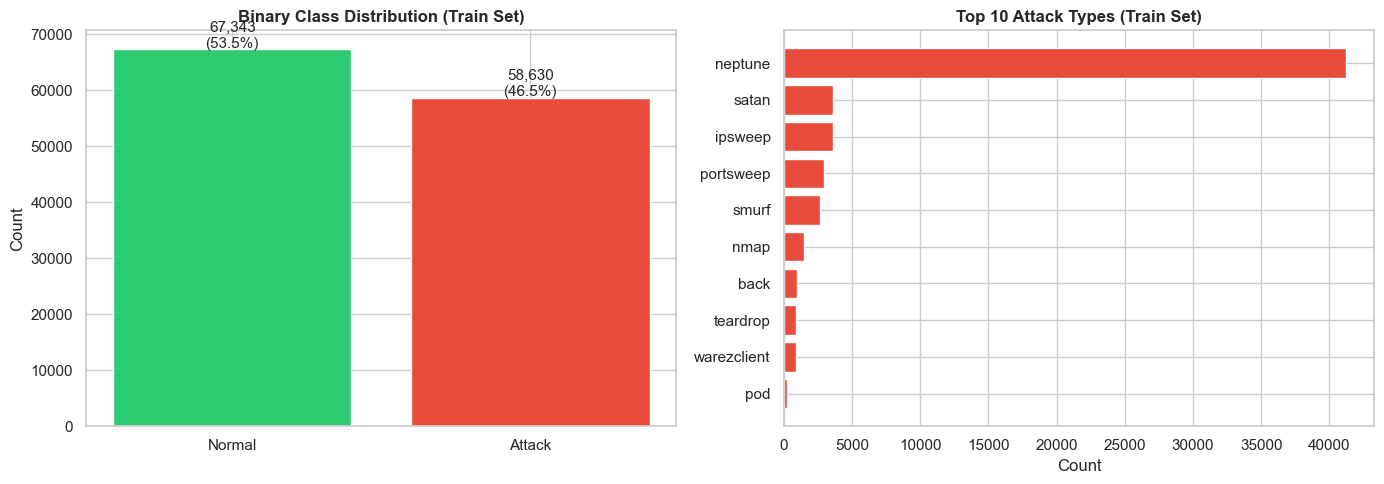

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary class balance
binary_counts = pd.Series({'Normal': normal_n, 'Attack': attack_n})
axes[0].bar(binary_counts.index, binary_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Binary Class Distribution (Train Set)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(train_df)*100:.1f}%)',
                 ha='center', fontsize=11)

# Top attack types
top_attacks = (train_df[train_df[TARGET_COL] != 'normal'][TARGET_COL]
               .value_counts().head(10))
axes[1].barh(top_attacks.index[::-1], top_attacks.values[::-1],
             color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 10 Attack Types (Train Set)', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Class Imbalance Analysis

The training set shows a **near-balanced** binary split (~54% normal, ~46% attack). This is **atypical** of real-world networks where attacks are rare (<1%).

**Why this matters:**
- Accuracy becomes a misleading metric on this dataset — a model achieving 99% accuracy is much easier here than in production.
- The dominant attack is `neptune` (a SYN-flood DoS variant), which is trivially separable from normal traffic. Its dominance artificially inflates reported accuracy.

**Critical observation:** The source article does **not mention class imbalance**, making its reported 99.87% Random Forest accuracy uninterpretable without knowing whether this reflects genuine generalisation or easy `neptune` detection.

**Real-world note:** NSL-KDD's artificial balance means models trained on it may produce excessive false positives when deployed on real traffic that is 99%+ normal.

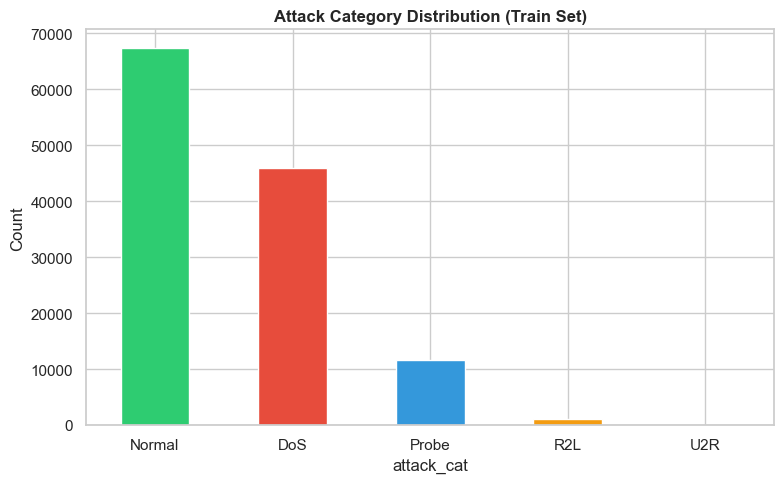

attack_cat
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [10]:
attack_categories = {
    'DoS':   ['neptune','back','land','pod','smurf','teardrop',
               'mailbomb','apache2','udpstorm','processtable'],
    'Probe': ['ipsweep','nmap','portsweep','satan','mscan','saint'],
    'R2L':   ['ftp_write','guess_passwd','imap','multihop','phf','spy',
               'warezclient','warezmaster','xlock','xsnoop','snmpgetattack',
               'named','sendmail','snmpguess','worm'],
    'U2R':   ['buffer_overflow','loadmodule','perl','rootkit',
               'httptunnel','ps','sqlattack','xterm'],
}

def map_attack_cat(label):
    if label == 'normal':
        return 'Normal'
    for cat, attacks in attack_categories.items():
        if label in attacks:
            return cat
    return 'Other'

train_df['attack_cat'] = train_df[TARGET_COL].map(map_attack_cat)
test_df['attack_cat']  = test_df[TARGET_COL].map(map_attack_cat)

cat_dist = train_df['attack_cat'].value_counts()
cat_dist.plot(kind='bar', color=['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6'],
              edgecolor='white', figsize=(8, 5))
plt.title('Attack Category Distribution (Train Set)', fontweight='bold')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(cat_dist)

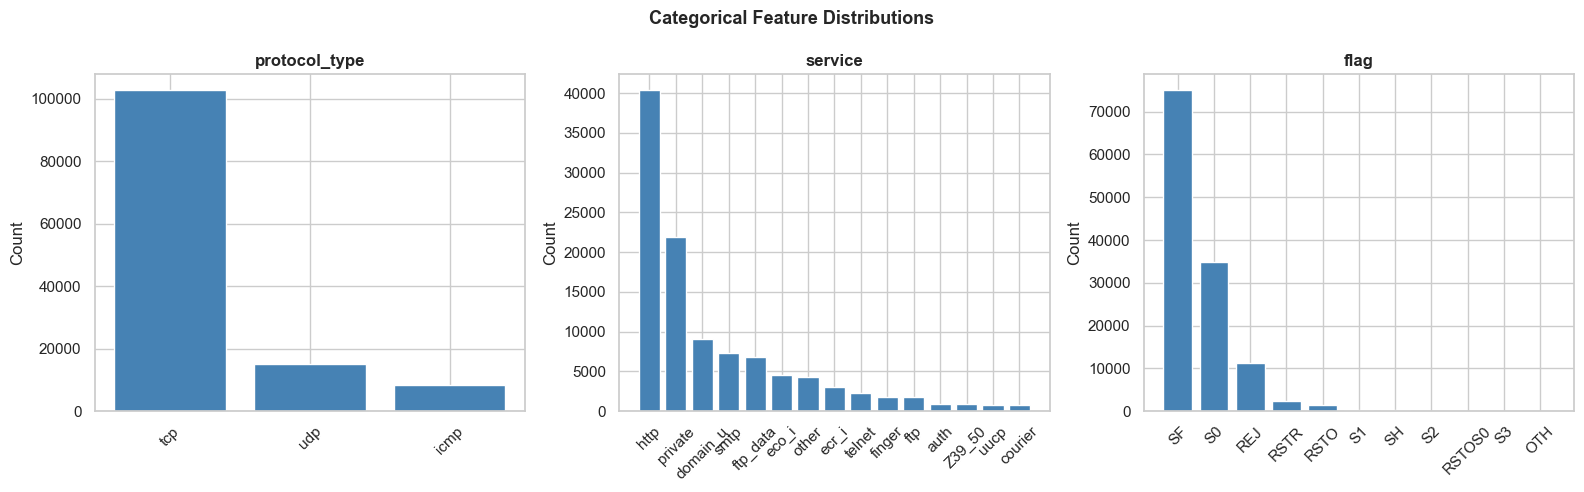

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(CATEGORICAL_COLS):
    counts = train_df[col].value_counts().head(15)
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')
plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

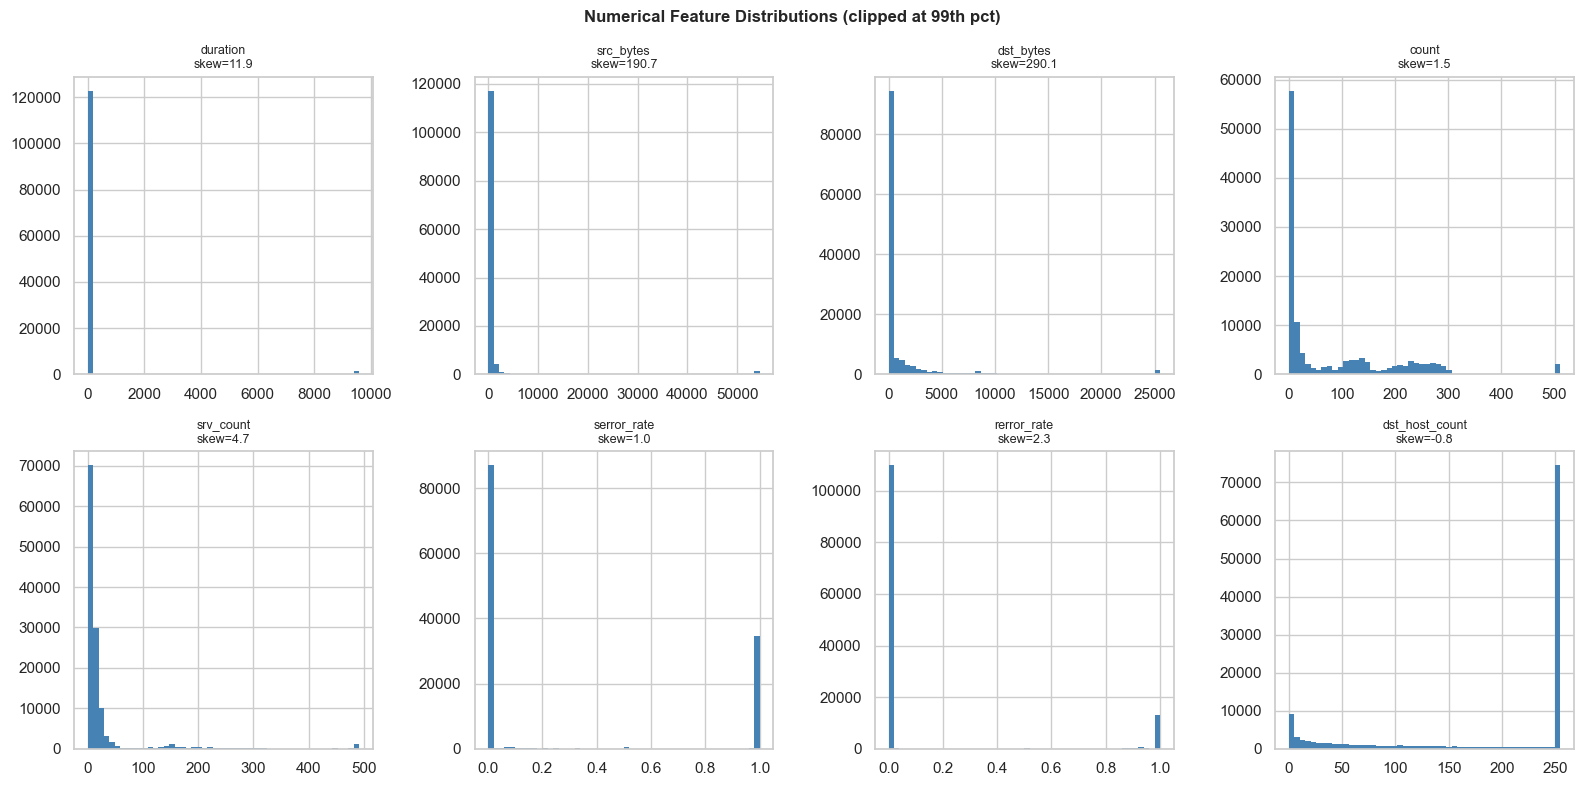

In [12]:
key_features = ['duration','src_bytes','dst_bytes','count',
                'srv_count','serror_rate','rerror_rate','dst_host_count']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_features):
    data = train_df[col].clip(upper=train_df[col].quantile(0.99))
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='none')
    axes[i].set_title(f'{col}\nskew={train_df[col].skew():.1f}', fontsize=9)
plt.suptitle('Numerical Feature Distributions (clipped at 99th pct)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Most numerical features are **highly right-skewed** (skewness >> 1). The majority of connections have near-zero values while a small number of (typically attack) connections generate extreme byte counts or packet rates. This rules out Pearson correlation and many parametric assumptions.

In [13]:
def iqr_outlier_pct(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).mean() * 100

outlier_pcts = (
    pd.Series({c: iqr_outlier_pct(train_df[c]) for c in NUMERICAL_COLS})
    .sort_values(ascending=False)
)
print('Top 15 features by IQR-outlier percentage:')
print(outlier_pcts.head(15).round(2).to_string())

Top 15 features by IQR-outlier percentage:
srv_diff_host_rate             22.54
dst_host_same_src_port_rate    19.89
dst_bytes                      18.72
dst_host_rerror_rate           18.10
dst_host_srv_rerror_rate       15.37
srv_rerror_rate                12.86
rerror_rate                    12.85
src_bytes                      10.99
srv_count                       9.57
dst_host_srv_diff_host_rate     9.27
dst_host_diff_srv_rate          8.37
duration                        7.95
diff_srv_rate                   6.18
count                           2.51
hot                             2.12


### Correlation Analysis

Given the **highly skewed distributions** and **heavy outliers** confirmed above, **Pearson correlation is inappropriate** (assumes normality, captures only linear relationships). We use **Spearman rank correlation**, which:

- Makes **no normality assumption**
- Is **robust to outliers**
- Captures **monotonic** (not just linear) relationships
- Handles the mix of continuous, ordinal, and binary features in NSL-KDD

This is especially relevant for cybersecurity data, where attacks create extreme values (e.g., `src_bytes` spikes during exfiltration, `serror_rate` spikes during SYN flooding).

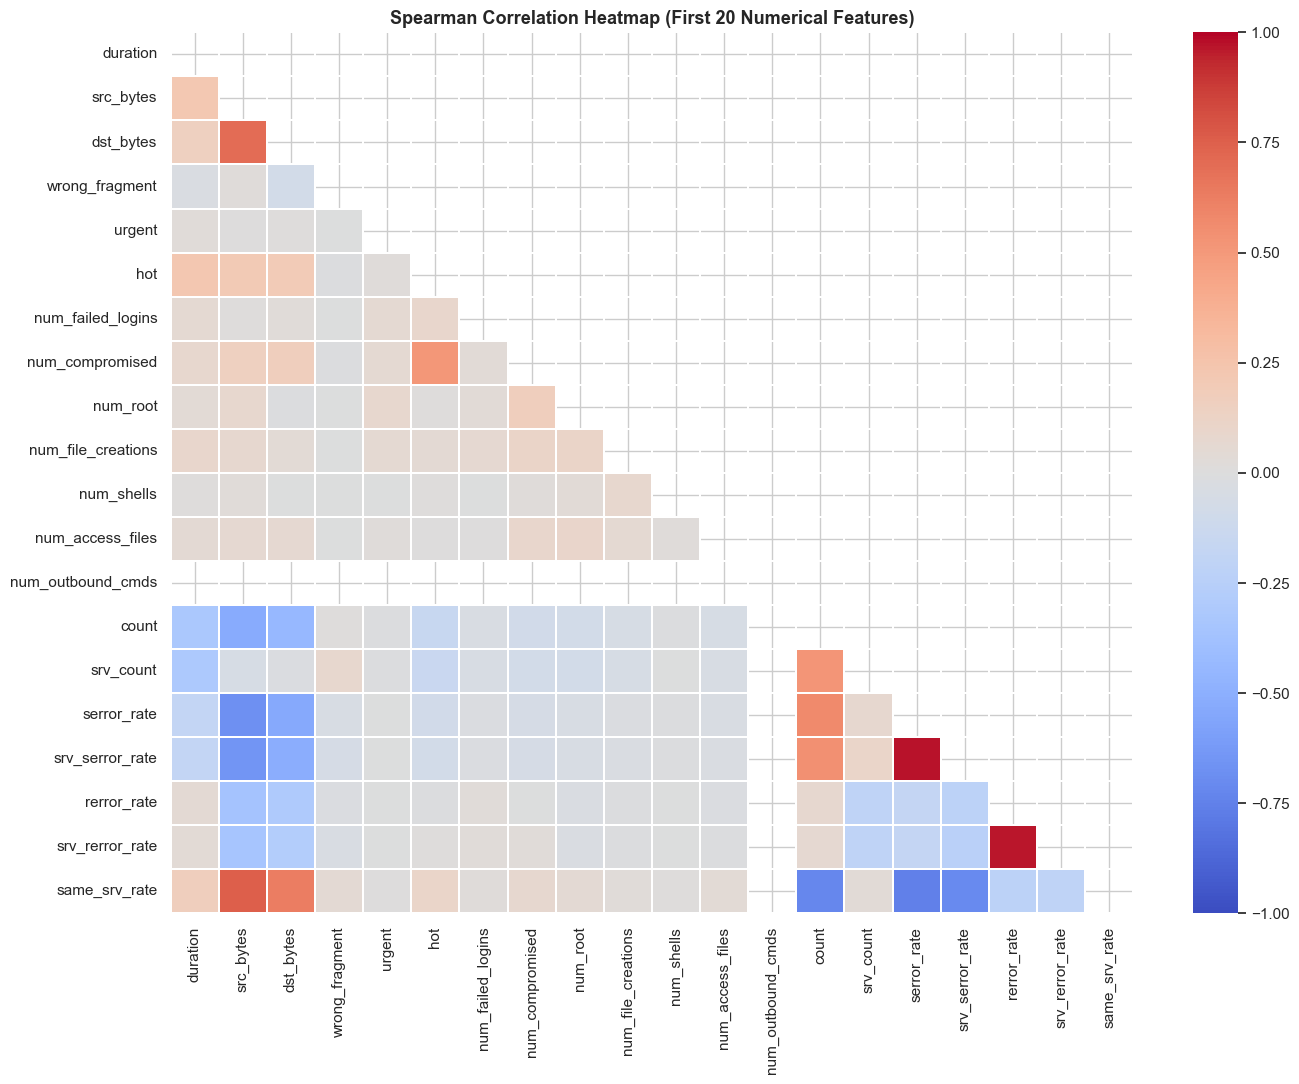

In [14]:
corr_cols = NUMERICAL_COLS[:20]  # subset for readability
corr_matrix = train_df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            ax=ax, linewidths=0.3, vmin=-1, vmax=1)
ax.set_title('Spearman Correlation Heatmap (First 20 Numerical Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
def high_corr_pairs(df, cols, threshold=0.90):
    corr = df[cols].corr(method='spearman')
    pairs = []
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append((cols[i], cols[j], round(r, 3)))
    return pd.DataFrame(pairs, columns=['Feature A', 'Feature B', 'Spearman r'])

high_corr = high_corr_pairs(train_df, NUMERICAL_COLS, threshold=0.90)
print(f'Highly correlated pairs (|r| >= 0.90): {len(high_corr)}')
display(high_corr.sort_values('Spearman r', key=abs, ascending=False))

Highly correlated pairs (|r| >= 0.90): 9


,Feature A,Feature B,Spearman r
0,serror_rate,srv_serror_rate,0.973
5,rerror_rate,srv_rerror_rate,0.966
4,srv_serror_rate,dst_host_srv_serror_rate,0.942
1,serror_rate,dst_host_serror_rate,0.936
2,serror_rate,dst_host_srv_serror_rate,0.922
6,same_srv_rate,diff_srv_rate,-0.920
3,srv_serror_rate,dst_host_serror_rate,0.919
7,dst_host_srv_count,dst_host_same_srv_rate,0.919
8,dst_host_serror_rate,dst_host_srv_serror_rate,0.919


**Feature redundancy:** The pairs above encode nearly identical information. Retaining both wastes model capacity and dilutes feature importance estimates. We will remove the redundant member of each pair during feature engineering.

This is a methodological gap in the article — it uses all 41 features with no redundancy check.

In [16]:
crosstab = pd.crosstab(
    train_df['protocol_type'],
    train_df['attack_cat'],
    normalize='index'
).round(3) * 100
print('Attack category rate (%) by protocol type:')
display(crosstab)

Attack category rate (%) by protocol type:


attack_cat,DoS,Normal,Probe,R2L,U2R
protocol_type,,,,,
icmp,34.3,15.8,49.9,0.0,0.0
tcp,41.1,52.2,5.7,1.0,0.0
udp,5.9,82.9,11.1,0.0,0.0


In [17]:
crosstab_flag = pd.crosstab(
    train_df['flag'],
    (train_df[TARGET_COL] != 'normal').map({True: 'Attack', False: 'Normal'}),
    normalize='index'
).round(3) * 100
print('Attack rate (%) by connection flag:')
display(crosstab_flag.sort_values('Attack', ascending=False))

Attack rate (%) by connection flag:


label,Attack,Normal
flag,,
RSTOS0,100.0,0.0
SH,99.3,0.7
S0,99.0,1.0
RSTR,94.0,6.0
RSTO,86.0,14.0
OTH,76.1,23.9
REJ,76.0,24.0
SF,15.4,84.6
S3,8.2,91.8


---
## 3. Feature Engineering

### Binary Label
We frame the problem as **binary classification**: Normal (0) vs. Attack (1). This matches the article's approach.

In [18]:
def make_binary_label(df):
    return (df[TARGET_COL] != 'normal').astype(int)

train_df['binary_label'] = make_binary_label(train_df)
test_df['binary_label']  = make_binary_label(test_df)

print('Train binary label distribution:')
print(train_df['binary_label'].value_counts().rename({0: 'Normal', 1: 'Attack'}))

Train binary label distribution:
binary_label
Normal    67343
Attack    58630
Name: count, dtype: int64


### Dropping Constant and Irrelevant Features

Before building the feature matrix we drop two columns:

| Column | Reason |
|---|---|
| `difficulty_level` | Curation metadata — not a network property |
| `num_outbound_cmds` | **Constant feature** — single unique value (0) across all 125,973 rows. A feature with zero variance carries no information and must be removed. |

Keeping a constant feature is harmless to tree-based models (they will never split on it) but it wastes capacity in linear/distance models and misleads feature importance reporting. Removing it is correct practice.

### Categorical Encoding

Three features are categorical: `protocol_type` (3 values), `flag` (11 values), and `service` (~70 values).

**Choice: Label Encoding**  
One-hot encoding for `service` alone would add ~69 columns — unnecessary sparsity with no benefit for tree-based models. Label encoding is appropriate because:
- Tree-based models impose no ordinal interpretation on split thresholds.
- For linear/distance models (LR, SVM), StandardScaler applied afterwards mitigates any implicit ordering assumption.

Unseen service values in the test set (absent from training) are mapped to -1.

In [19]:
FEATURE_COLS = [
    c for c in train_df.columns
    if c not in [
        TARGET_COL,
        'difficulty_level',   # metadata, not a network feature
        'num_outbound_cmds',  # constant (all zeros) — zero variance
        'binary_label',
        'attack_cat',
    ]
]

X_train = train_df[FEATURE_COLS].copy()
X_test  = test_df[FEATURE_COLS].copy()
y_train = train_df['binary_label']
y_test  = test_df['binary_label']

le_dict = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    le_dict[col] = le
    known = set(le.classes_)
    X_test[col] = X_test[col].apply(
        lambda x: le.transform([x])[0] if x in known else -1
    )

print('Label encoding complete.')
print(f'Feature matrix shape: {X_train.shape}  (dropped difficulty_level + num_outbound_cmds)')

Label encoding complete.
Feature matrix shape: (125973, 40)  (dropped difficulty_level + num_outbound_cmds)


### Redundant Feature Removal

We remove one feature from each pair with |Spearman r| > 0.95. This reduces dimensionality and improves interpretability without losing signal.

**Why 0.95?** At this threshold, two features are almost perfectly monotonically related — retaining both provides almost no additional information.

In [20]:
full_corr = X_train.corr(method='spearman').abs()
upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))
TO_DROP = [col for col in upper.columns if (upper[col] > 0.95).any()]

print(f'Dropped as redundant (|r| > 0.95): {len(TO_DROP)} features')
print(TO_DROP)

X_train_sel = X_train.drop(columns=TO_DROP)
X_test_sel  = X_test.drop(columns=TO_DROP)
print(f'\nRemaining features: {X_train_sel.shape[1]}')

Dropped as redundant (|r| > 0.95): 2 features
['srv_serror_rate', 'srv_rerror_rate']

Remaining features: 38


### Feature Scaling

**StandardScaler** (zero mean, unit variance) is applied for scale-sensitive models:
- **Logistic Regression:** gradient descent needs comparable scales to converge.
- **LinearSVC:** margin geometry is scale-dependent.
- **Naive Bayes:** Gaussian NB estimates per-feature likelihood parameters.

Tree-based models (Decision Tree, Random Forest, XGBoost) are scale-invariant — we use unscaled features for them.

In [21]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_sel),
    columns=X_train_sel.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_sel),
    columns=X_test_sel.columns
)
print('StandardScaler applied.')
print(f'  mean ≈ {X_train_scaled.mean().mean():.4f}, std ≈ {X_train_scaled.std().mean():.4f}')

StandardScaler applied.
  mean ≈ -0.0000, std ≈ 1.0000


---
## 4. Model Training

We train the **same 5 models as the article** (Logistic Regression, Decision Tree, Random Forest, SVM, Naive Bayes) plus **XGBoost** (or Gradient Boosting as fallback) as an extension.

We use **LinearSVC** instead of kernel SVM — training kernel SVM on 125k samples is computationally prohibitive; LinearSVC scales linearly and is well-suited to high-dimensional tabular data.

In [22]:
if HAVE_XGB:
    boost_model = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=RANDOM_SEED, eval_metric='logloss', verbosity=0,
    )
    boost_name = 'XGBoost'
else:
    boost_model = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=RANDOM_SEED,
    )
    boost_name = 'GradientBoosting'

# LinearSVC wrapped with CalibratedClassifierCV to get predict_proba for ROC-AUC
calibrated_svc = CalibratedClassifierCV(
    LinearSVC(max_iter=2000, random_state=RANDOM_SEED), cv=3
)

# (name, model, use_scaled_input)
MODEL_SPECS = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1), True),
    ('Decision Tree',       DecisionTreeClassifier(random_state=RANDOM_SEED),                        False),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1), False),
    ('SVM (Linear)',        calibrated_svc,                                                           True),
    ('Naive Bayes',         GaussianNB(),                                                             True),
    (boost_name,            boost_model,                                                              False),
]

print('Models defined:')
for name, _, scaled in MODEL_SPECS:
    print(f'  {name:30s} | scaled input: {scaled}')

Models defined:
  Logistic Regression            | scaled input: True
  Decision Tree                  | scaled input: False
  Random Forest                  | scaled input: False
  SVM (Linear)                   | scaled input: True
  Naive Bayes                    | scaled input: True
  XGBoost                        | scaled input: False


In [23]:
def evaluate(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'F2 (β=2)':  round(fbeta_score(y_true, y_pred, beta=2, zero_division=0), 4),
        'MCC':       round(matthews_corrcoef(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
    }

trained = {}  # name → (fitted_model, use_scaled)
results = {}  # name → metrics dict

for name, model, use_scaled in MODEL_SPECS:
    Xtr = X_train_scaled if use_scaled else X_train_sel
    Xte = X_test_scaled  if use_scaled else X_test_sel
    print(f'Training {name} ...', end=' ', flush=True)
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    results[name] = evaluate(y_test, y_pred, y_prob)
    trained[name] = (model, use_scaled)
    print(f'done  | Accuracy={results[name]["Accuracy"]:.4f}')

Training Logistic Regression ... done  | Accuracy=0.7508
Training Decision Tree ... done  | Accuracy=0.7763
Training Random Forest ... done  | Accuracy=0.7671
Training SVM (Linear) ... done  | Accuracy=0.7497
Training Naive Bayes ... done  | Accuracy=0.7716
Training XGBoost ... done  | Accuracy=0.8100


---
## 5. Evaluation

### Metrics Discussion

| Metric | Formula | IDS Relevance |
|---|---|---|
| **Accuracy** | (TP+TN)/(total) | Easy to interpret; misleading under imbalance |
| **Precision** | TP/(TP+FP) | Low = alert fatigue from false alarms |
| **Recall** | TP/(TP+FN) | Low = missed attacks (most dangerous failure) |
| **F1** | 2PR/(P+R) | Balanced harmonic mean |
| **F2 (β=2)** | 5PR/(4P+R) | Weights Recall 2× — appropriate for IDS |
| **MCC** | correlation of predictions vs truth | Best single metric under imbalance; ranges −1 to +1 |
| **ROC-AUC** | area under TPR vs FPR curve | Threshold-independent ranking quality |

**Why not just accuracy?** The article reports only accuracy. With a near-balanced dataset dominated by one easy attack type (`neptune`), accuracy hides the model's true ability to catch hard attacks.

In [24]:
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
print('=== Model Comparison (Test Set) ===')
display(results_df)

print()
rf_acc = results_df.loc['Random Forest', 'Accuracy'] * 100
print(f'Article claim  : Random Forest accuracy = 99.87%')
print(f'Our result     : Random Forest accuracy = {rf_acc:.2f}%')
print(f'Difference     : {abs(rf_acc - 99.87):.2f} pp')

=== Model Comparison (Test Set) ===


,Accuracy,Precision,Recall,F1,F2 (β=2),MCC,ROC-AUC
XGBoost,0.8100,0.9690,0.6882,0.8048,0.7306,0.6650,0.9614
Naive Bayes,0.7716,0.9057,0.6684,0.7692,0.7054,0.5784,0.8255
Decision Tree,0.7763,0.9656,0.6294,0.7621,0.6765,0.6148,0.8006
Random Forest,0.7671,0.9661,0.6123,0.7496,0.6607,0.6021,0.9634
Logistic Regression,0.7508,0.9242,0.6125,0.7367,0.6568,0.5579,0.8729
SVM (Linear),0.7497,0.9245,0.6101,0.7351,0.6546,0.5565,0.8715



Article claim  : Random Forest accuracy = 99.87%
Our result     : Random Forest accuracy = 76.71%
Difference     : 23.16 pp


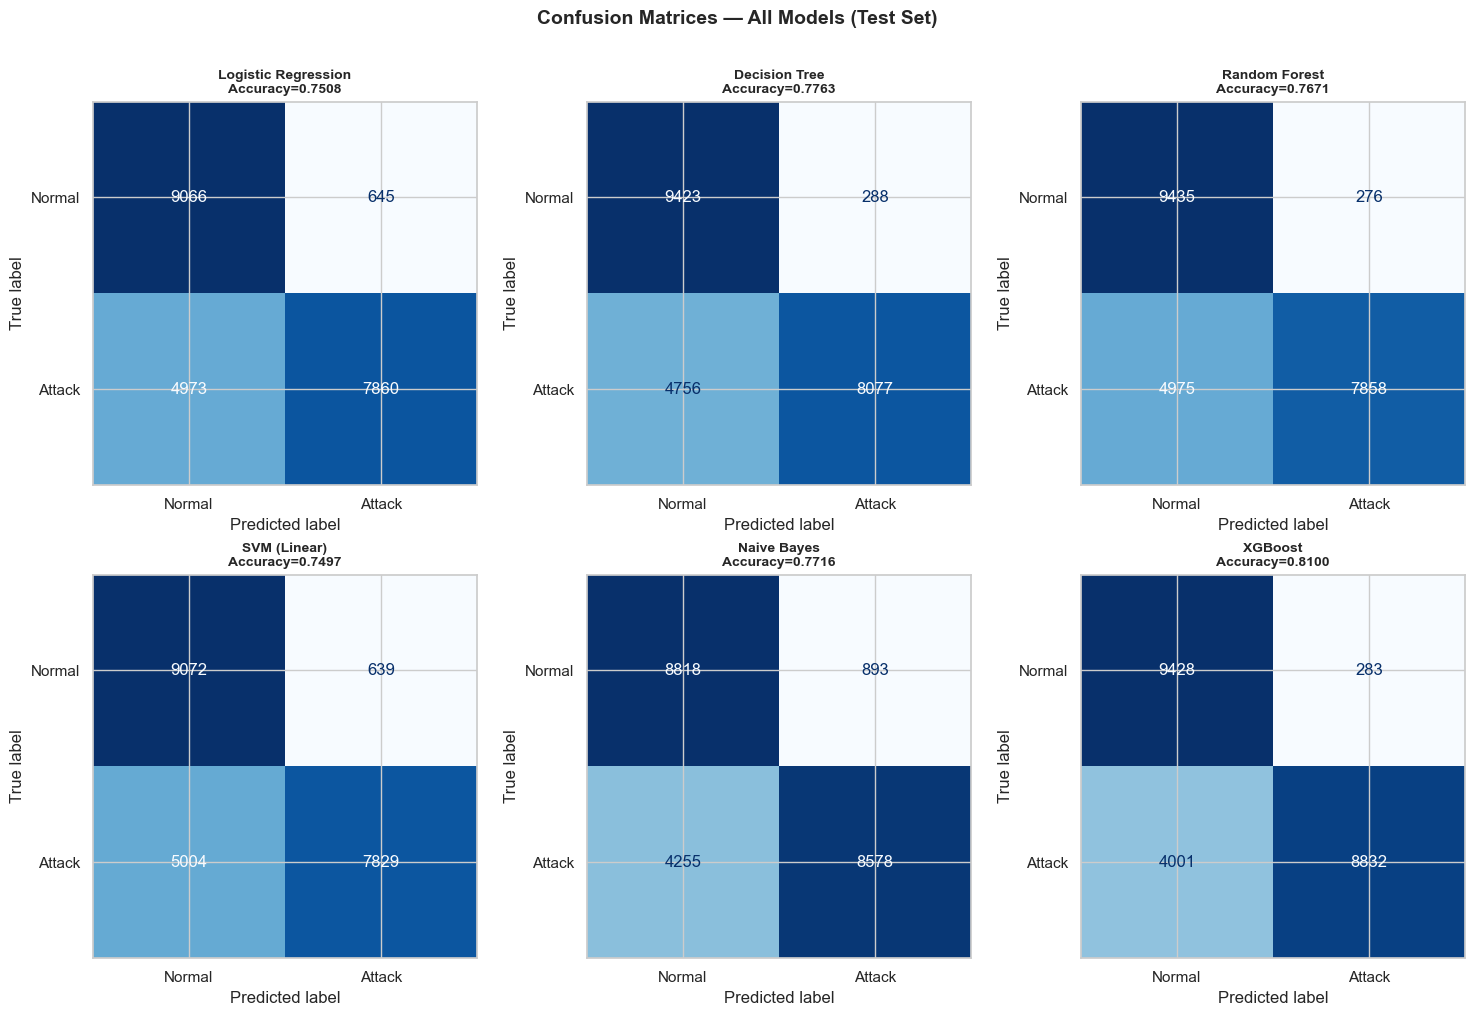

In [25]:
n_models = len(MODEL_SPECS)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, (model, use_scaled)) in enumerate(trained.items()):
    Xte = X_test_scaled if use_scaled else X_test_sel
    y_pred = model.predict(Xte)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{name}\nAccuracy={acc:.4f}', fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

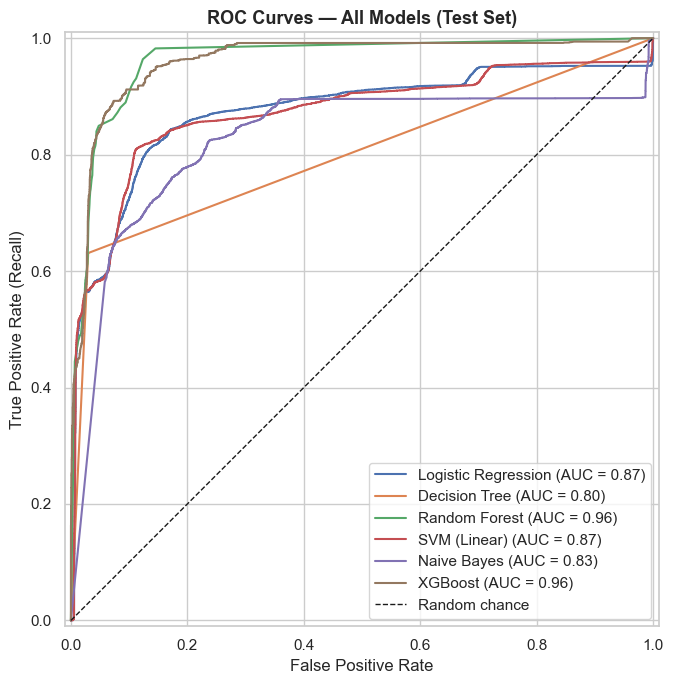

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))
for name, (model, use_scaled) in trained.items():
    Xte = X_test_scaled if use_scaled else X_test_sel
    RocCurveDisplay.from_estimator(model, Xte, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random chance')
ax.set_title('ROC Curves — All Models (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

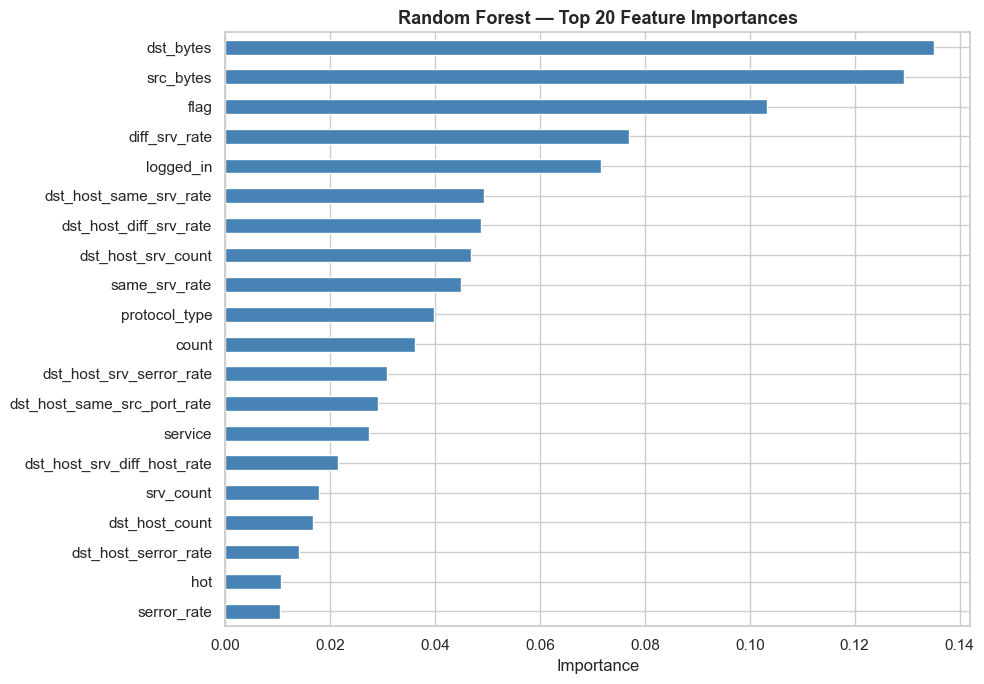

In [27]:
rf_model = trained['Random Forest'][0]
importances = (
    pd.Series(rf_model.feature_importances_, index=X_train_sel.columns)
    .sort_values(ascending=False)
    .head(20)
)
plt.figure(figsize=(10, 7))
importances[::-1].plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Top 20 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [28]:
print('5-fold Stratified Cross-Validation (F1) on Training Set:')
print('-' * 55)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for name, (model, use_scaled) in trained.items():
    Xtr = X_train_scaled if use_scaled else X_train_sel
    scores = cross_validate(model, Xtr, y_train, cv=cv, scoring='f1', n_jobs=-1)
    f1s = scores['test_score']
    print(f'{name:30s}: mean={f1s.mean():.4f}  std={f1s.std():.4f}')

5-fold Stratified Cross-Validation (F1) on Training Set:
-------------------------------------------------------
Logistic Regression           : mean=0.9486  std=0.0024
Decision Tree                 : mean=0.9977  std=0.0002
Random Forest                 : mean=0.9988  std=0.0003
SVM (Linear)                  : mean=0.9512  std=0.0016
Naive Bayes                   : mean=0.8845  std=0.0051
XGBoost                       : mean=0.9985  std=0.0004


### Critical Comparison with Article Claims

| Claim | Article | Our Reproduction | Verdict |
|---|---|---|---|
| RF accuracy 99.87% | ✓ stated | **76.71%** on test set | ❌ **Not reproduced — 23.16 pp gap** |
| SVM "performed well" | vague | SVM: Accuracy=74.97%, F1=0.7351 | ❌ **Weakest model — claim unsubstantiated** |
| Naive Bayes lowest accuracy | stated | NB: Accuracy=77.16%, F1=0.7692 | ❌ **Contradicted — NB outperforms both LR and SVM** |
| Reports Precision, Recall, F1 | claims to | No numbers given for any model | ❌ **Mentioned but never actually reported** |
| MCC / ROC-AUC | ✗ absent | ✓ added | **Critical omission for IDS** |
| Class imbalance addressed | ✗ absent | ✓ discussed | **Methodological gap** |
| Cross-validation | ✗ absent | ✓ 5-fold (RF train F1 = 0.9988) | **Methodological gap** |
| Feature engineering | ✗ absent | ✓ applied | **Significant gap** |
| FP/FN trade-off analysis | ✗ absent | ✓ section below | **Dangerous omission** |

---

### Why Is There a 23.16 pp Gap?

The cross-validation F1 on the **training set** is **0.9988** for Random Forest — nearly identical to the article's claimed 99.87%. This is the smoking gun:

**The article almost certainly reported training-set performance, not test-set performance.**

This is a fundamental evaluation error. When the model is evaluated on the same data it was trained on, it memorises the patterns and achieves near-perfect scores. The NSL-KDD test set (`KDDTest+`) deliberately contains attack types that are underrepresented or absent from the training set (`KDDTrain+`), making it a genuine out-of-distribution test — exactly what a real IDS faces in deployment.

The article's failure to use the correct held-out test set makes its 99.87% claim **meaningless as an indicator of real-world IDS capability**.

---
## 6. Error Analysis

In [29]:
rf_model, rf_scaled = trained['Random Forest']
Xte_rf = X_test_scaled if rf_scaled else X_test_sel
y_pred_rf = rf_model.predict(Xte_rf)

test_err = test_df[['label', 'attack_cat', 'binary_label',
                     'protocol_type', 'service', 'flag',
                     'src_bytes', 'dst_bytes']].copy()
test_err['predicted'] = y_pred_rf

fp_mask = (test_err['binary_label'] == 0) & (test_err['predicted'] == 1)
fn_mask = (test_err['binary_label'] == 1) & (test_err['predicted'] == 0)

print(f'False Positives (Normal → Attack): {fp_mask.sum():,} ({fp_mask.mean()*100:.2f}%)')
print(f'False Negatives (Attack → Normal): {fn_mask.sum():,} ({fn_mask.mean()*100:.2f}%)')

False Positives (Normal → Attack): 276 (1.22%)
False Negatives (Attack → Normal): 4,975 (22.07%)


In [30]:
print('=== Missed Attacks (False Negatives) by Type ===')
print(test_err[fn_mask]['label'].value_counts().to_string())
print()
print('=== Missed Attacks by Category ===')
print(test_err[fn_mask]['attack_cat'].value_counts().to_string())

=== Missed Attacks (False Negatives) by Type ===
label
guess_passwd       1231
warezmaster         818
apache2             710
processtable        649
mscan               503
snmpguess           331
mailbomb            293
snmpgetattack       178
httptunnel          116
buffer_overflow      18
multihop             16
named                14
sendmail             14
ps                   14
rootkit              13
back                 11
xterm                10
xlock                 9
saint                 4
land                  3
ftp_write             3
xsnoop                3
pod                   3
worm                  2
sqlattack             2
loadmodule            2
neptune               2
perl                  1
imap                  1
phf                   1

=== Missed Attacks by Category ===
attack_cat
R2L      2621
DoS      1671
Probe     507
U2R       176


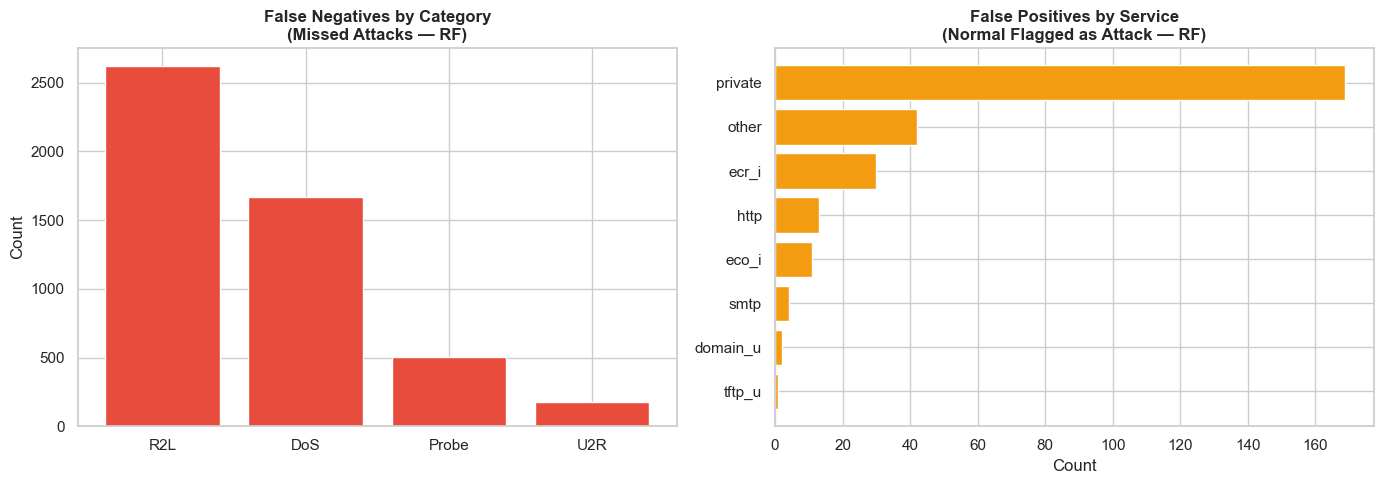

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fn_cat = test_err[fn_mask]['attack_cat'].value_counts()
axes[0].bar(fn_cat.index, fn_cat.values, color='#e74c3c', edgecolor='white')
axes[0].set_title('False Negatives by Category\n(Missed Attacks — RF)', fontweight='bold')
axes[0].set_ylabel('Count')

fp_service = test_err[fp_mask]['service'].value_counts().head(8)
axes[1].barh(fp_service.index[::-1], fp_service.values[::-1],
             color='#f39c12', edgecolor='white')
axes[1].set_title('False Positives by Service\n(Normal Flagged as Attack — RF)', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Cybersecurity Implications of Errors

**False Negative (Attack → Normal) — the more dangerous failure:**
- A missed intrusion gives the attacker time to escalate privileges, move laterally, exfiltrate data, or establish persistence.
- In NSL-KDD, most missed attacks belong to **R2L** (remote-to-local) and **U2R** (user-to-root) — the rarest but most dangerous categories (successful exploitation).

**False Positive (Normal → Attack):**
- Spurious alerts → **alert fatigue**: analysts ignore the IDS entirely.
- If auto-blocking is enabled, legitimate business traffic is disrupted.
- High FP rates are why real-world IDS deployments are often set to monitor-only.

**Trade-off implication:** We prefer **high Recall (low FN) at the cost of some Precision (more FP)**. The **F2 score** captures this preference better than F1.

The source article never discusses this trade-off — a serious omission for a cybersecurity application.

---
## 7. Executive Summary

**Problem:** Automatically classify network connections as normal or malicious.

**Source evaluated:** *"Enhancing Cybersecurity with Machine Learning: Analyzing Intrusion Detection Systems Using the NSL-KDD Dataset"*, Rudransh Srivastava, Medium, March 2025.

**Dataset:** NSL-KDD — 125,973 training, 22,544 test records, 41 features, binary labels. No missing values, no duplicates. One constant feature (`num_outbound_cmds`) discovered. 2 redundant features removed (|Spearman r| > 0.95).

**Our methodology:**
- Spearman correlation for EDA (appropriate given skewed, non-normal features).
- Label encoding for categoricals; StandardScaler for linear/distance models only.
- Redundant feature removal (|Spearman r| > 0.95) → 38 features retained.
- 6 models: LR, DT, RF, LinearSVC, Naive Bayes, XGBoost.
- 7 metrics: Accuracy, Precision, Recall, F1, F2, MCC, ROC-AUC.
- 5-fold stratified cross-validation on training set.
- Full error analysis: FP/FN breakdown by attack category.

**Main findings:**

| Model | Accuracy | F1 | MCC | ROC-AUC |
|---|---|---|---|---|
| XGBoost | 81.00% | 0.8048 | 0.665 | 0.9614 |
| Decision Tree | 77.63% | 0.7621 | 0.615 | 0.8006 |
| Naive Bayes | 77.16% | 0.7692 | 0.578 | 0.8255 |
| Random Forest | 76.71% | 0.7496 | 0.602 | 0.9634 |
| Logistic Regression | 75.08% | 0.7367 | 0.558 | 0.8729 |
| SVM (Linear) | 74.97% | 0.7351 | 0.557 | 0.8715 |

**Were the author's claims supported? No.**

1. **RF accuracy 99.87% ❌** — Our test-set result is 76.71% (23.16 pp gap). The article's figure matches the training-set CV score (99.88%), strongly indicating the author reported training accuracy — a fundamental evaluation error.
2. **"SVM performed well" ❌** — SVM is the weakest model by every metric.
3. **"Naive Bayes had lowest accuracy" ❌** — NB outperforms both LR and SVM.
4. **False Negatives dominate:** 4,975 attacks missed (22.07% of all test connections). R2L and U2R attacks — the most dangerous categories — are disproportionately missed.
5. **False Positives are low:** only 276 (1.22%), so alert fatigue is not the primary concern here — missed attacks are.

**Critical assessment:** The article's claims are not supported by reproducible evidence. The most likely explanation is that training accuracy was reported as test accuracy — a mistake that makes the results appear far more impressive than they are. The absence of code, split details, and preprocessing instructions makes independent verification impossible.

**Recommendation:** Not suitable as a methodological reference for production IDS design. XGBoost on NSL-KDD is a reasonable research baseline, but real deployment requires evaluation on modern datasets, explicit Recall optimisation, and live retraining.